<a href="https://colab.research.google.com/github/2024akcs4377f-spec/ML-assignment-2/blob/Decision-tree-and-random-forest/Decision_tree_and_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

### Load Datasets

In [2]:
# Load the datasets
X_train = pd.read_csv('/content/x_train.csv')
y_train = pd.read_csv('/content/y_train.csv')
X_test = pd.read_csv('/content/x_test.csv')
y_test = pd.read_csv('/content/y_test.csv')

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# Display the first few rows of the training data
print("\nX_train head:")
display(X_train.head())
print("\ny_train head:")
display(y_train.head())

X_train shape: (537, 8)
y_train shape: (537, 1)
X_test shape: (231, 8)
y_test shape: (231, 1)

X_train head:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,1,95.0,60.0,18.0,58.0,23.9,0.260,22
1,5,105.0,72.0,29.0,325.0,36.9,0.159,28
2,0,135.0,68.0,42.0,250.0,42.3,0.365,24
3,4,131.0,68.0,21.0,166.0,33.1,0.160,28
4,1,103.0,30.0,38.0,83.0,43.3,0.183,33



y_train head:


,Outcome
0,0
1,0
2,1
3,0
4,0


### Decision Tree Classifier

Decision Tree Accuracy: 0.6970
Decision Tree Precision: 0.7027
Decision Tree Recall: 0.6970
Decision Tree F1-Score: 0.6994

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.75      0.76       151
           1       0.56      0.60      0.58        80

    accuracy                           0.70       231
   macro avg       0.67      0.67      0.67       231
weighted avg       0.70      0.70      0.70       231



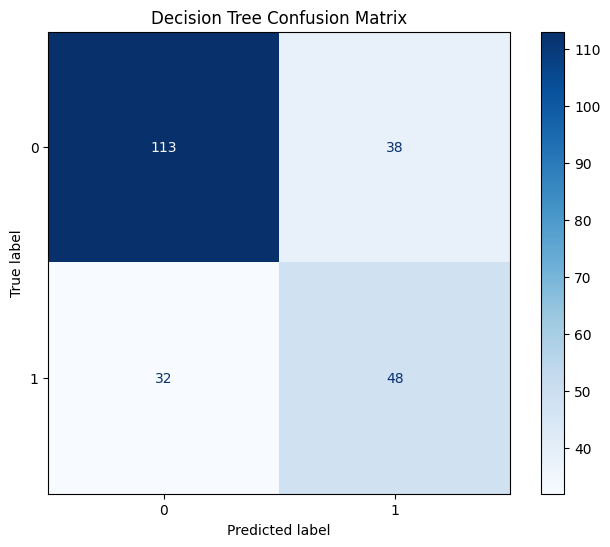

In [3]:
# Initialize and train the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dt_classifier.predict(X_test)

# Evaluate the Decision Tree model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, average='weighted', zero_division=0)
recall_dt = recall_score(y_test, y_pred_dt, average='weighted', zero_division=0)
f1_dt = f1_score(y_test, y_pred_dt, average='weighted', zero_division=0)

print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")
print(f"Decision Tree Precision: {precision_dt:.4f}")
print(f"Decision Tree Recall: {recall_dt:.4f}")
print(f"Decision Tree F1-Score: {f1_dt:.4f}")

print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt, zero_division=0))

# Plot Confusion Matrix for Decision Tree
fig_dt, ax_dt = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(dt_classifier, X_test, y_test, ax=ax_dt, cmap=plt.cm.Blues)
ax_dt.set_title("Decision Tree Confusion Matrix")
plt.show()


### Random Forest Classifier

Random Forest Accuracy: 0.7489
Random Forest Precision: 0.7521
Random Forest Recall: 0.7489
Random Forest F1-Score: 0.7503

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.79      0.81       151
           1       0.63      0.66      0.65        80

    accuracy                           0.75       231
   macro avg       0.72      0.73      0.73       231
weighted avg       0.75      0.75      0.75       231



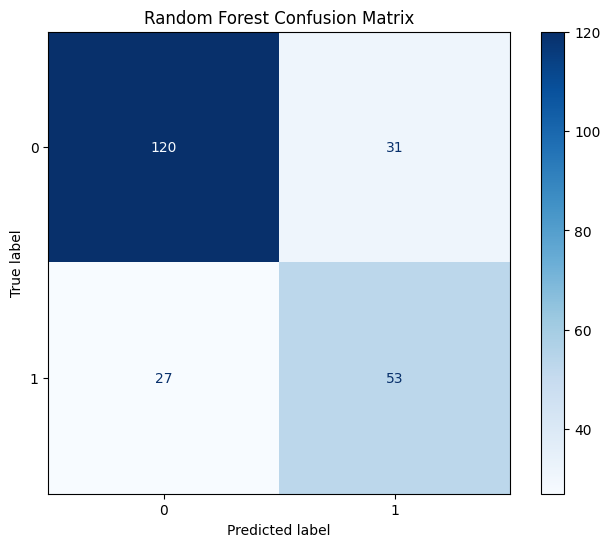

In [6]:
# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train, y_train.values.ravel())

# Make predictions on the test set
y_pred_rf = rf_classifier.predict(X_test)

# Evaluate the Random Forest model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Precision: {precision_rf:.4f}")
print(f"Random Forest Recall: {recall_rf:.4f}")
print(f"Random Forest F1-Score: {f1_rf:.4f}")

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

# Plot Confusion Matrix for Random Forest
fig_rf, ax_rf = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(rf_classifier, X_test, y_test.values.ravel(), ax=ax_rf, cmap=plt.cm.Blues)
ax_rf.set_title("Random Forest Confusion Matrix")
plt.show()

### Model Performance Comparison

In [5]:
# Create a DataFrame to compare model performances
comparison_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_dt, accuracy_rf],
    'Precision': [precision_dt, precision_rf],
    'Recall': [recall_dt, recall_rf],
    'F1-Score': [f1_dt, f1_rf]
})

print("\nModel Performance Comparison:")
display(comparison_df.set_index('Model'))


Model Performance Comparison:


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Decision Tree,0.696970,0.702714,0.696970,0.699375
Random Forest,0.748918,0.752128,0.748918,0.750295
